
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---
## Trabajo práctico entregable - Parte 1

In [4]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn

seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [5]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [6]:
df[:10]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0
3,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),7800000.0,6000000.0,Cobro parte del salario en dólares,1470,3+ sueldos,Mix de las anteriores,No,...,NaN,NaN,NaN,60,Hombre Cis,Sí,NaN,True,Senior,7800000.0
4,Jujuy,Full-Time,Contractor,3500000.0,3200000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,NaN,NaN,NaN,29,Hombre Cis,Sí,Nose,True,Semi-Senior,3500000.0
5,Corrientes,Part-Time,Contractor,400000.0,400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1450,No,No recibo bono,No,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,22,Hombre Cis,No,"Devligths, Banco de Corrientes, Poder Judicial",True,Junior,400000.0
6,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,8460000.0,7200000.0,Cobro todo el salario en dólares,6000,De uno a tres sueldos,Performance de la compañía,Uno,...,0.0,Bruto,Responder sobre mis estudios,47,Hombre Cis,Sí,"COELSA, Mercado Libre, Santander Tecnología",True,Senior,8460000.0
7,Buenos Aires,Full-Time,Contractor,6400000.0,6400000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,10.0,Porcentaje de mi sueldo bruto,Responder sobre mis estudios,29,Hombre Cis,Sí,NaN,True,Semi-Senior,6400000.0
8,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),3000000.0,2500000.0,Mi sueldo está dolarizado (pero cobro en moned...,no está dolarizado cobro en peso.,Menos de un sueldo,Performance de la compañía,Más de tres,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,40,Mujer Cis,Sí,"Lemón, Salesforce y otras",True,Semi-Senior,3000000.0
9,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,6075000.0,6075000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,Uno,...,NaN,NaN,NaN,30,Mujer Cis,Sí,NaN,True,Senior,6075000.0


In [7]:
df.columns.tolist()

['work_province',
 'work_dedication',
 'work_contract_type',
 'salary_monthly_BRUTO',
 'salary_monthly_NETO',
 'salary_in_usd',
 'salary_last_dollar_value',
 'salary_has_bonus',
 'salary_bonus_tied_to',
 'salary_inflation_adjustment',
 'salary_percentage_inflation_adjustment',
 'salary_month_last_inflation_adjustment',
 'salary_comparison_last_semester',
 'salary_benefit',
 'salary_satisfaction',
 'work_looking_for_job',
 'profile_various_jobs',
 'company_main_activity',
 'profile_years_experience',
 'work_years_in_company',
 'work_years_in_current_position',
 'work_people_in_charge_of',
 'tools_platform',
 'tools_programming_languages',
 'tools_frameworks',
 'tools_data_bases',
 'tools_qa_testing',
 'company_employee_number',
 'work_work_modality',
 'company_days_in_the_office',
 'salary_inflation_policy',
 'company_reduction_of_employees',
 'company_recommended',
 'tools_copilotchatgpt',
 'vibe_coding',
 'tools_ide_ia',
 'algo_que_quieras_decir_sobre_tu_trabajo',
 'salir_o_seguir_con

# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

In [8]:
# complete here if you want to include more columns
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO', 'work_dedication', 'salary_in_usd', 'work_seniority']

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [9]:
df.tools_programming_languages[:3]

0    .NET, C#, CSS, Go, HTML, Java, Javascript, SQL
1                   .NET, C#, HTML, Javascript, SQL
2                                           Go, SQL
Name: tools_programming_languages, dtype: str

Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen.

No es necesario entender este código en profundidad, aunque sí es un buen ejercicio.

In [10]:
# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df.loc[:, 'cured_programming_languages'] = df.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,salary_in_usd,work_seniority,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"


En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

In [11]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:15]

,frequency,count
0,sql,2217
1,javascript,1860
2,python,1774
3,html,1385
4,typescript,1136
5,css,885
6,bash/shell,881
7,java,787
8,php,566
9,.net,530


## Filtrado de lenguajes relevantes

El siguiente código permite seleccionar sólo las filas donde el valor de la columna `programming_language` se encuentre en la lista `interesting_languages`.

In [12]:
# Extraemos los valores de la columna que tiene los nombres (0 al 14)
# Usamos .iloc para ser precisos: todas las filas hasta la 15, columna de los nombres
interesting_languages = language_count.iloc[:15, 0].tolist()
print(interesting_languages)

['sql', 'javascript', 'python', 'html', 'typescript', 'css', 'bash/shell', 'java', 'php', '.net', 'c#', 'go', 'kotlin', 'c++', 'vba']


In [13]:
# Filter out languages that we want to exclude
# Complete here with your selected list.
filtered_df_lang = df_lang[df_lang.programming_language.isin(interesting_languages)]
filtered_df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,salary_in_usd,work_seniority,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Mi sueldo está dolarizado (pero cobro en moned...,Senior,"[.net, c#, css, go, html, java, javascript, sql]"


In [14]:
# Definimos qué respuestas excluiremos (las que indican cobro en dólares)
# Dejamos fuera "Cobro todo el salario en dólares" y "Cobro parte..."
# Los NaN se mantienen porque se asumen como salario en pesos.
exclude_usd = ['Cobro todo el salario en dólares', 'Cobro parte del salario en dólares']

df_sub_poblacion = df[
    (df['work_dedication'] == 'Full-Time') &
    (~df['salary_in_usd'].isin(exclude_usd))
].copy()

print(f"Registros después de filtrar por Jornada Full-Time y Moneda Nacional: {len(df_sub_poblacion)}")

Registros después de filtrar por Jornada Full-Time y Moneda Nacional: 3535


In [15]:
# Utilizamos los percentiles 5% y 95% de la distribución para eliminar outliers.
# El salario neto asociado al percentil del 5% se encuentra incluso por debajo del
# Salario Mínimo Vital y Móvil ($352.400 a febero 2026, # que coincide con la fecha de publicación
# de resultados de la encuesta -6 de marzo de 2026)

lower =  df_sub_poblacion['salary_monthly_NETO'].quantile(0.005)
upper = df_sub_poblacion['salary_monthly_NETO'].quantile(0.995)

#para tener otra opcion de corte
lower2 = df_sub_poblacion['salary_monthly_NETO'].quantile(0.025)
upper2 = df_sub_poblacion['salary_monthly_NETO'].quantile(0.975)
print('lim_inf0.5%= ',lower,'lim_sup0.5%= ',upper,'lim_inf2.5%= ',lower2,'lim_sup2.5%= ',upper2)
# Vamos a definir el df filtrado
df_final = df_sub_poblacion[
        (df_sub_poblacion['salary_monthly_NETO'].between(lower, upper))
]
print(f"Registros finales para el análisis: {len(df_final)}")

lim_inf0.5%=  260000.0 lim_sup0.5%=  11115793.135000033 lim_inf2.5%=  889650.0 lim_sup2.5%=  6712518.449999995
Registros finales para el análisis: 3399


In [16]:
# Estadística descriptiva DESPUÉS del filtrado
print("Estadísticas finales del salario neto (Sub-población limpia):")
display(df_final['salary_monthly_NETO'].describe().apply(lambda x: format(x, 'f')))

Estadísticas finales del salario neto (Sub-población limpia):


count        3399.000000
mean      2836753.745943
std       1442863.558298
min        260000.000000
25%       1800000.000000
50%       2549000.000000
75%       3547617.000000
max      10342432.000000
Name: salary_monthly_NETO, dtype: str

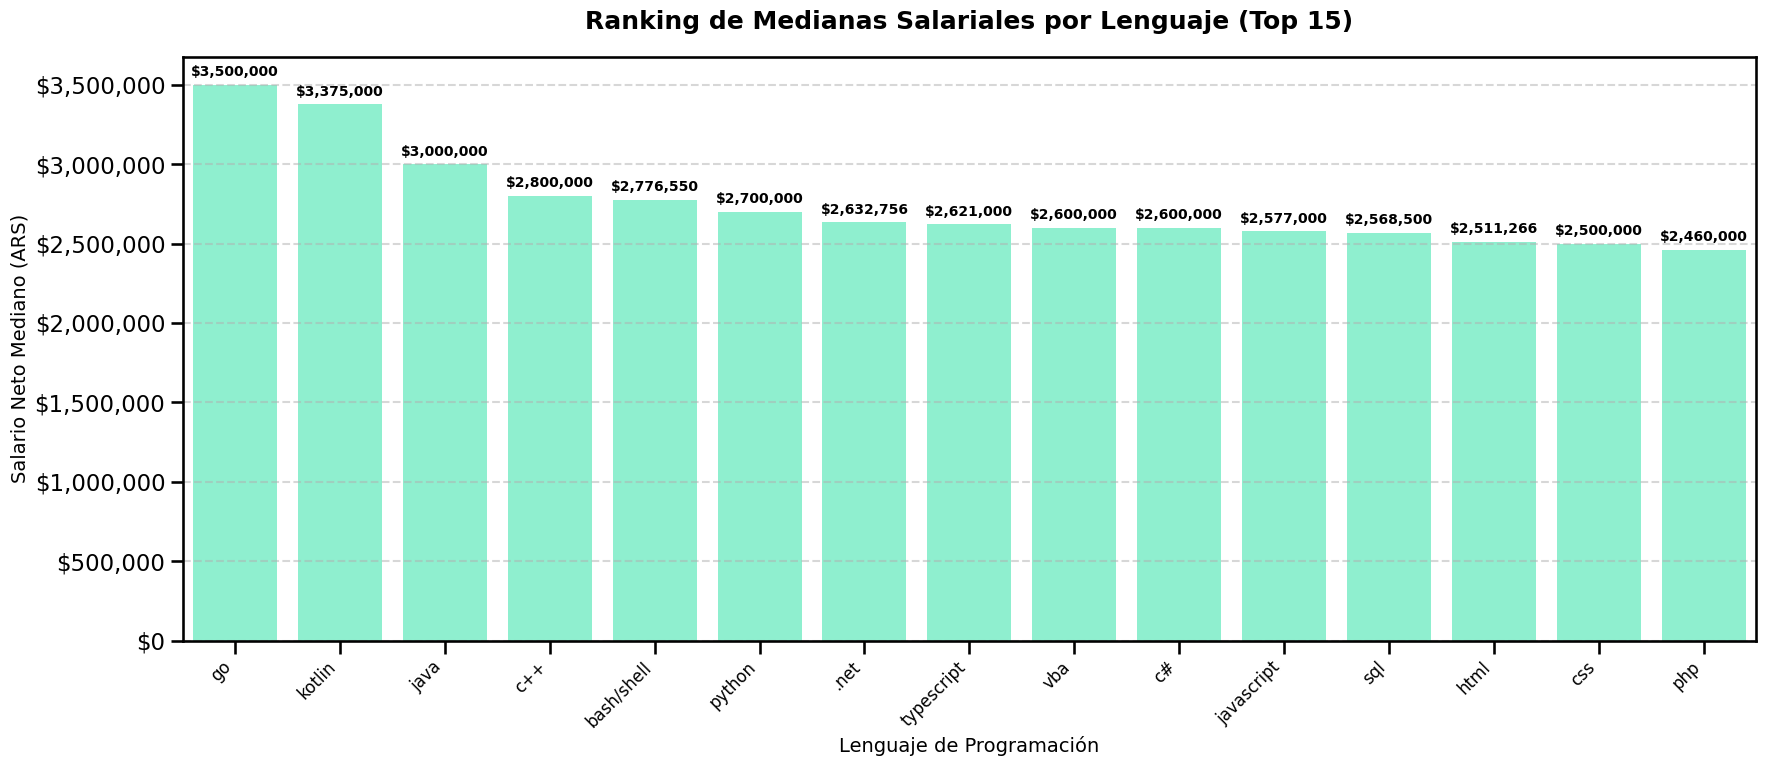

In [17]:
import matplotlib.ticker as ticker

df_filtered_for_analysis = filtered_df_lang[
    (filtered_df_lang['work_dedication'] == 'Full-Time') &
    (~filtered_df_lang['salary_in_usd'].isin(exclude_usd)) &
    (filtered_df_lang['salary_monthly_NETO'].between(lower, upper))
].copy()

# 1. Definimos el Top 15 de lenguajes
top_15_langs = df_filtered_for_analysis['programming_language'].value_counts().head(15).index
df_top15 = df_filtered_for_analysis[df_filtered_for_analysis['programming_language'].isin(top_15_langs)]

# 2. Calculamos el orden basado en la MEDIANA salarial de cada lenguaje
# Esto es vital para que el gráfico sea una "escalera" descendente
order_by_median = df_top15.groupby('programming_language')['salary_monthly_NETO']\
    .median().sort_values(ascending=False).index

# 3. Creamos el gráfico
plt.figure(figsize=(18, 8))
ax = seaborn.barplot(data=df_top15,
                     x='programming_language',
                     y='salary_monthly_NETO',
                     order=order_by_median,
                     color='aquamarine',
                     estimator='median',
                     errorbar=None)

# 4. Formateo de Ejes (Variable Continua)
def currency_format(x, pos):
    return f'${x:,.0f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Ranking de Medianas Salariales por Lenguaje (Top 15)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Lenguaje de Programación', fontsize=14)
plt.ylabel('Salario Neto Mediano (ARS)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

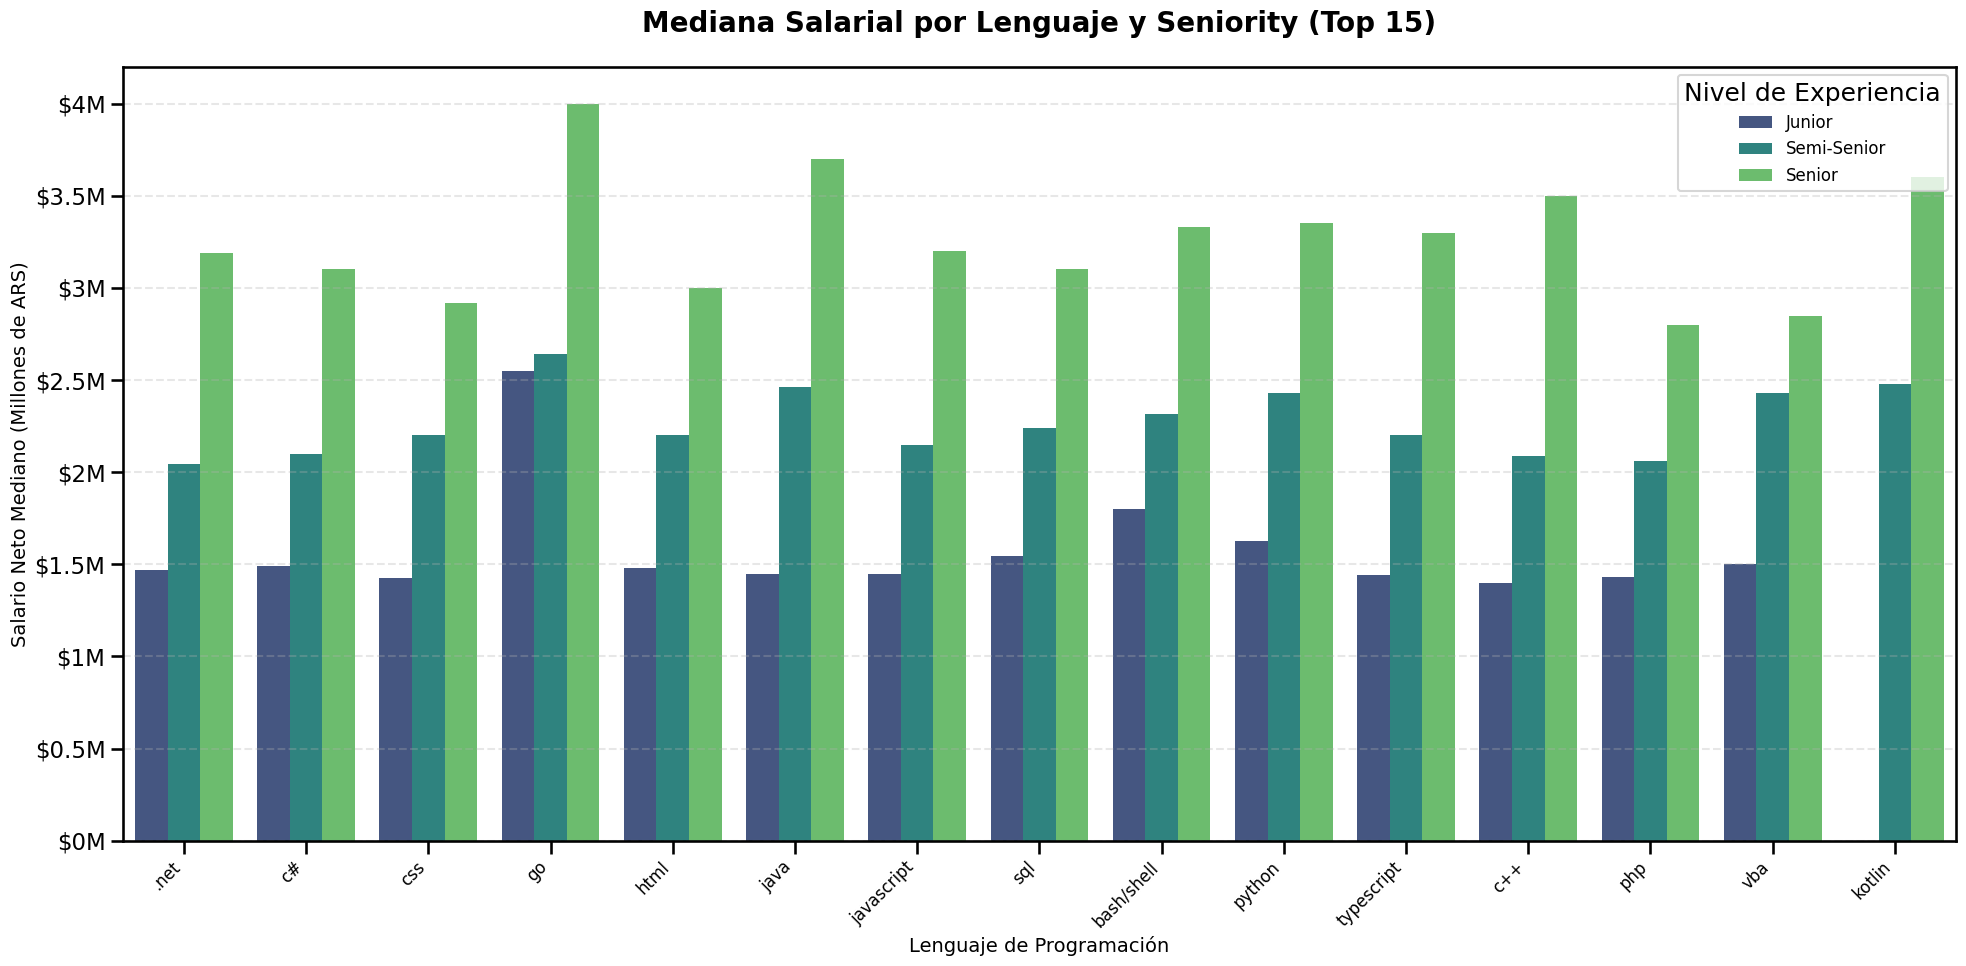

In [18]:
import matplotlib.ticker as ticker

# 1. Definimos el orden de Seniority para que las barras sigan una escala lógica
seniority_order = ['Junior', 'Semi-Senior', 'Senior']

# 2. Usamos el orden de lenguajes que ya calculamos (por mediana general)
# para que el gráfico mantenga una jerarquía visual.
plt.figure(figsize=(20, 10))

# 3. Creamos el gráfico con 'hue' para separar por Seniority
ax = seaborn.barplot(data=df_top15,
                     x='programming_language',
                     y='salary_monthly_NETO',
                     hue='work_seniority',
                     hue_order=seniority_order,
                     palette='viridis', # 'viridis' es excelente para escalas de progresión
                     estimator='median',
                     errorbar=None)

# 4. Formateo de Eje Y (Pesos Argentinos)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1e6:g}M'))

# 5. Detalles estéticos
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Mediana Salarial por Lenguaje y Seniority (Top 15)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Lenguaje de Programación', fontsize=14)
plt.ylabel('Salario Neto Mediano (Millones de ARS)', fontsize=14)
plt.legend(title='Nivel de Experiencia', loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

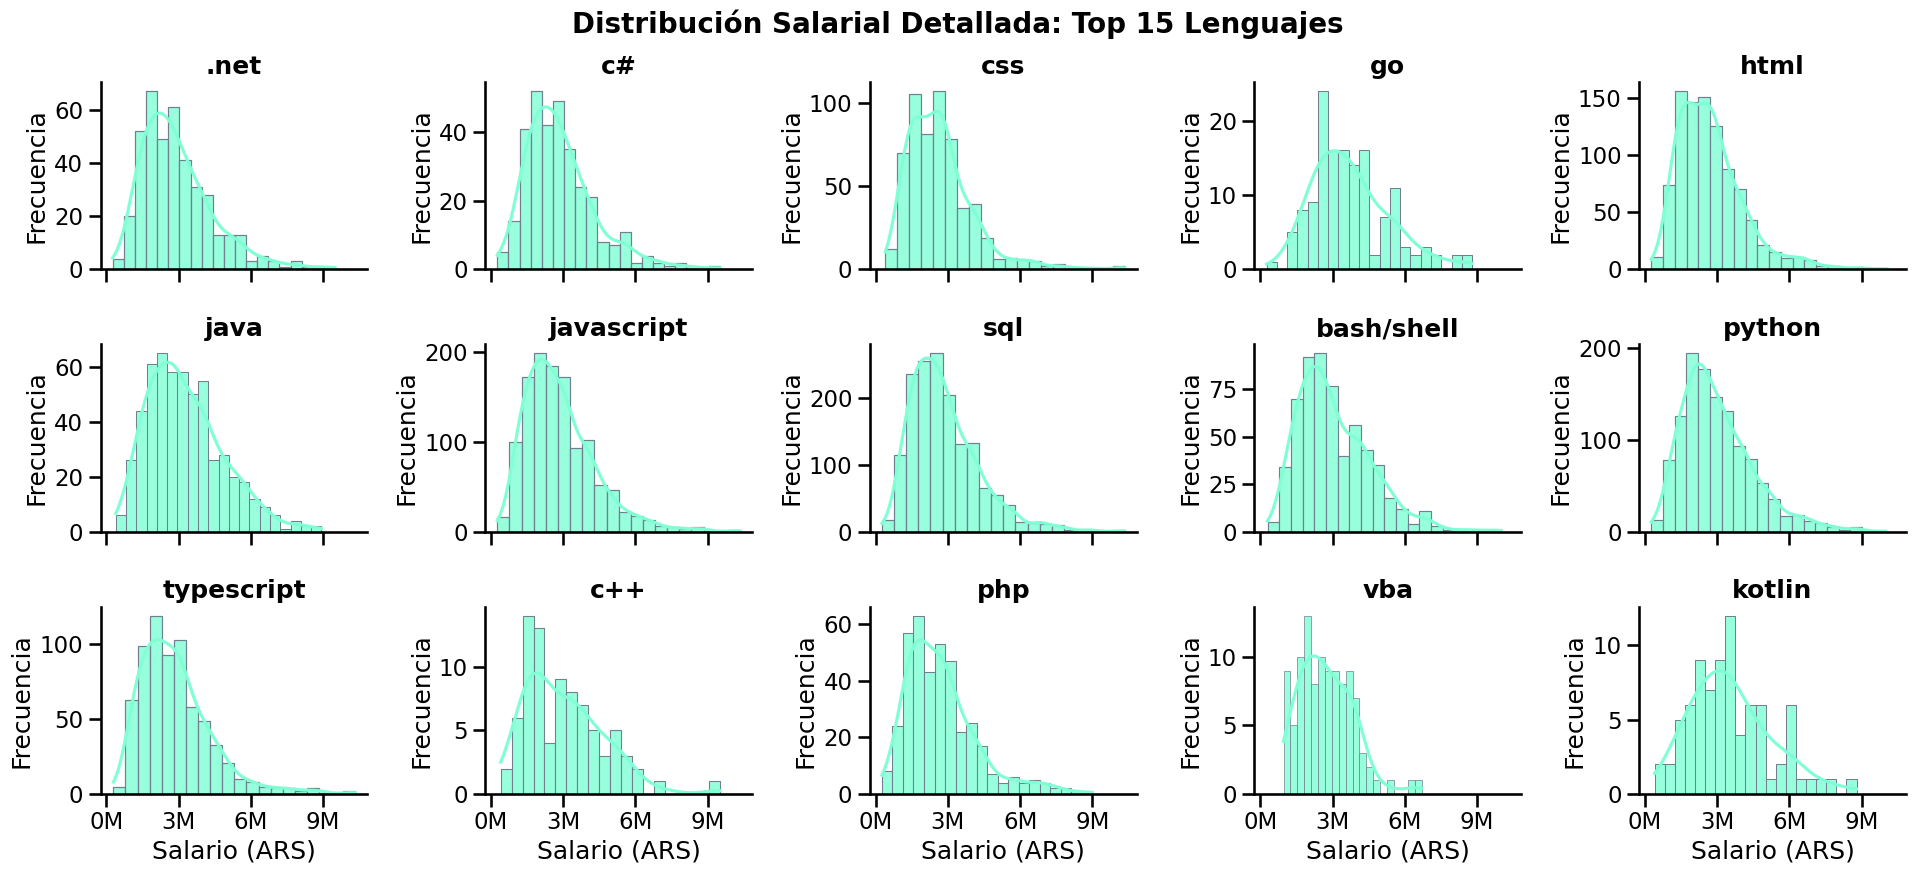

In [19]:
import matplotlib.ticker as ticker

# 1. Usamos el df_top15 que ya definimos antes
# 2. Creamos la grilla (3 filas x 5 columnas para los 15 lenguajes)
g = seaborn.FacetGrid(df_top15, col="programming_language", col_wrap=5,
                      height=3, aspect=1.3, sharex=True, sharey=False)

# 3. Dibujamos el histograma con la curva de densidad (KDE)
g.map(seaborn.histplot, "salary_monthly_NETO", bins=20, kde=True,
      color="aquamarine", edgecolor="slategray", alpha=0.8)

# 4. Formateo de Ejes para Variable Continua (en Millones)
def millions(x, pos):
    return f'{x/1e6:g}M'

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(millions))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    # Mejoramos la estética de las etiquetas
    ax.set_xlabel("Salario (ARS)")
    ax.set_ylabel("Frecuencia")

# 5. Título y ajuste final
g.set_titles(col_template="{col_name}", fontweight='bold')
plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Distribución Salarial Detallada: Top 15 Lenguajes', fontsize=20, fontweight='bold')

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_53028\3061417022.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.boxplot(data=df_top15,


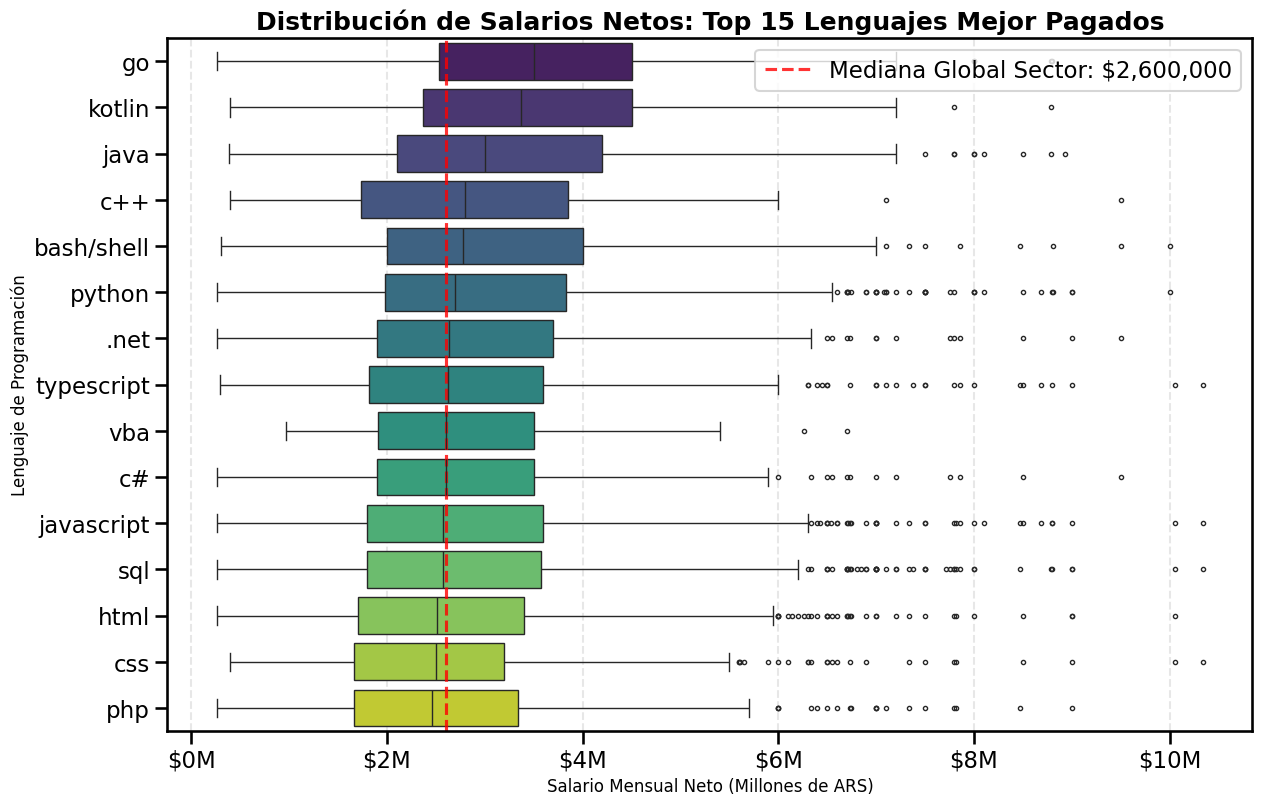

In [20]:
import matplotlib.ticker as ticker

# 1. Definimos el Top 15 de lenguajes usando el DataFrame correctamente filtrado
top_15_langs = df_filtered_for_analysis['programming_language'].value_counts().head(15).index
df_top15 = df_filtered_for_analysis[df_filtered_for_analysis['programming_language'].isin(top_15_langs)]

# 2. Calculamos el orden por MEDIANA para que el gráfico sea una "escalera"
order_top15 = df_top15.groupby('programming_language')['salary_monthly_NETO']\
    .median().sort_values(ascending=False).index

# 3. Creamos el gráfico
plt.figure(figsize=(14, 9))
ax = seaborn.boxplot(data=df_top15,
                    x='salary_monthly_NETO',
                    y='programming_language',
                    order=order_top15,
                    palette='viridis', # Gradiente que ayuda a ver la jerarquía
                    fliersize=3)        # Tamaño pequeño para los puntitos de outliers

# 4. Formateo del Eje X (Variable Continua en Millones)
def currency_format(x, pos):
    return f'${x/1e6:g}M'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(currency_format))

# 5. Detalles estéticos y línea de referencia
# Usamos df_filtered_for_analysis para calcular la mediana global para consistencia
median_global = df_filtered_for_analysis['salary_monthly_NETO'].median()
plt.axvline(median_global, color='red', linestyle='--', alpha=0.8,
            label=f'Mediana Global Sector: ${median_global:,.0f}')

plt.title('Distribución de Salarios Netos: Top 15 Lenguajes Mejor Pagados', fontsize=18, fontweight='bold')
plt.xlabel('Salario Mensual Neto (Millones de ARS)', fontsize=12)
plt.ylabel('Lenguaje de Programación', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_53028\1106185580.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = seaborn.violinplot(data=df_top15,


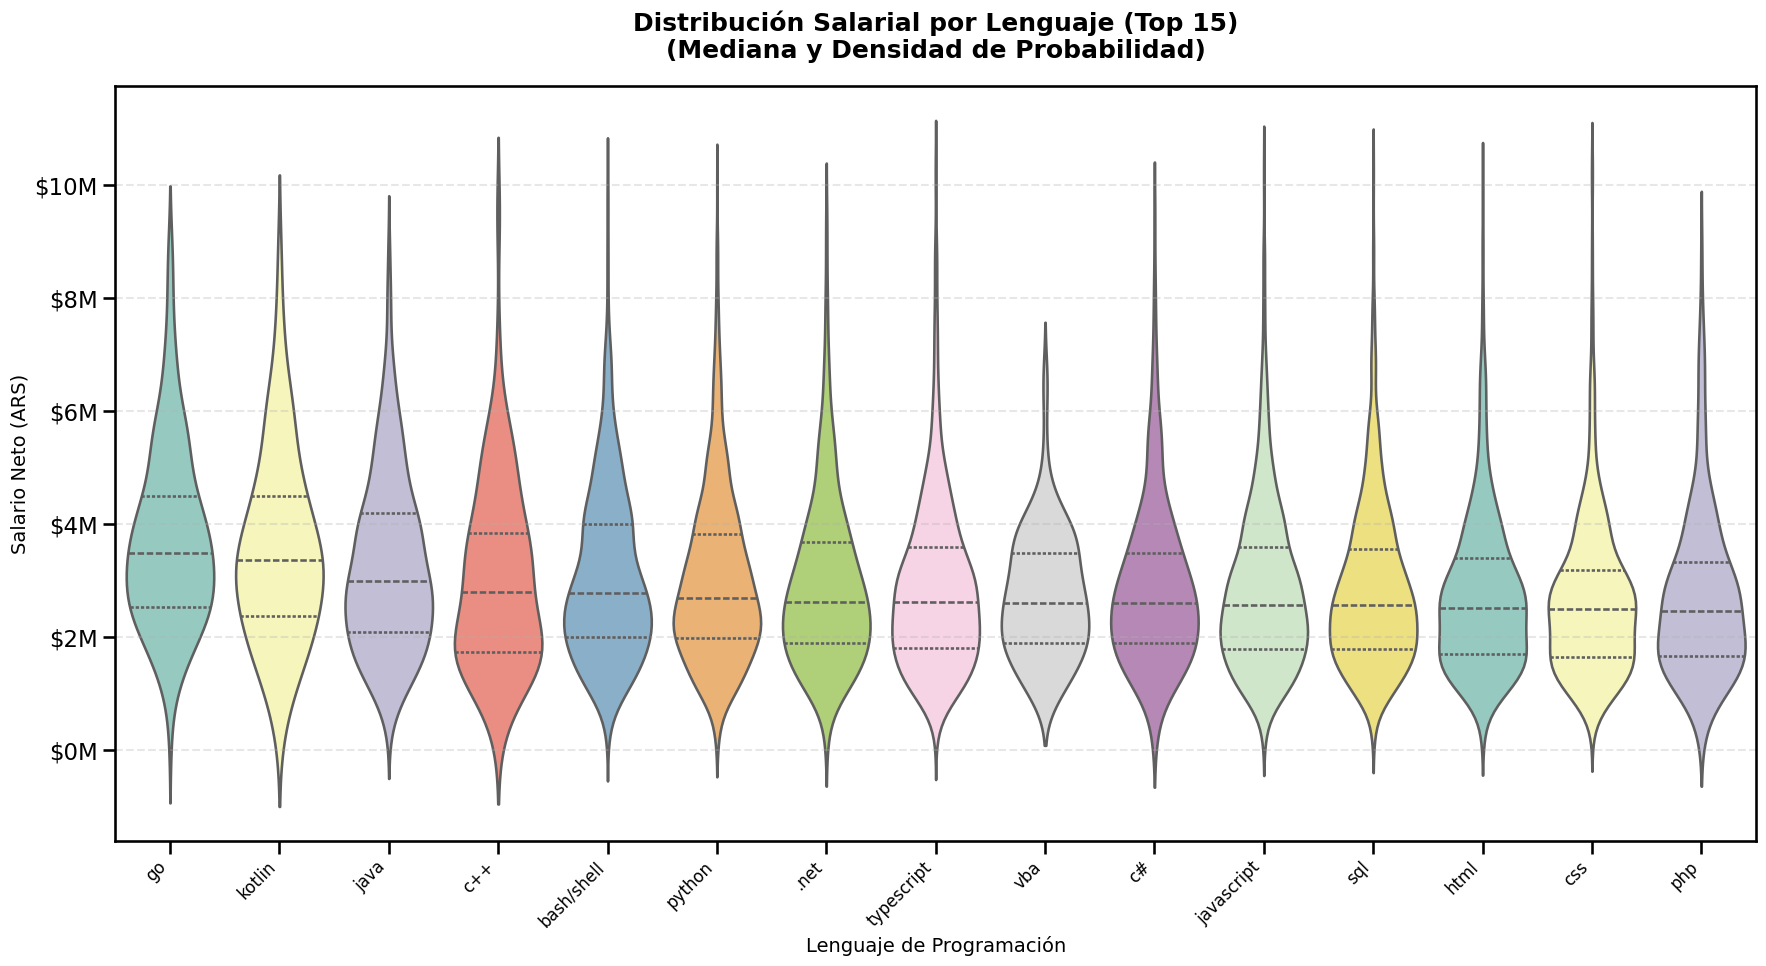

In [21]:
# 1. Usamos el mismo DataFrame filtrado
plt.figure(figsize=(18, 10))
# 2. Creamos el gráfico de violín
ax = seaborn.violinplot(data=df_top15,
                        x='programming_language',
                        y='salary_monthly_NETO',
                        order=order_by_median, # Mantenemos el orden por mediana para consistencia
                        palette='Set3',        # Una paleta suave para que se vean bien las densidades
                        inner='quartile',     # Muestra las líneas de los cuartiles dentro del violín
                        split=False)

# 3. Formateo de Ejes (Variable Continua)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(currency_format))

# 4. Detalles estéticos y etiquetas
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title('Distribución Salarial por Lenguaje (Top 15)\n(Mediana y Densidad de Probabilidad)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Lenguaje de Programación', fontsize=14)
plt.ylabel('Salario Neto (ARS)', fontsize=14)

# 5. Agregamos una grilla horizontal para facilitar la lectura de valores
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Informe de Análisis Salarial IT: Lenguajes, Seniority y Mercado Local**

Entendemos que es un sesgo pensar que un lenguaje se paga por sí solo; existen múltiples variables heterogéneas que lo afectan. Por ello, seleccionamos cuidadosamente columnas como seniority, work_dedication y salary_in_usd. Por este motivo, reformulamos la pregunta inicial:

####**¿Existen diferencias en el salario mediano de los programadores que utilizan los 15 lenguajes más populares, de acuerdo a las respuestas de la encuesta SYSARMY, considerando únicamente trabajadores con dedicación Full-Time que perciben su remuneración en moneda nacional?**

Lo primero que hicimos fue definir nuestra subpoblacion. Para garantizar un análisis libre de variables de confusión, aplicamos un filtrado estricto: solo trabajadores Full-Time con remuneración en moneda nacional. Mezclar sueldos en dólares o jornadas reducidas sesgaría el valor real de cada lenguaje en el mercado local. Tras este proceso, pasamos de 13.761 registros a una subpoblación limpia de 9.117 casos.

A su vez, para simplificar el análisis, también seleccionamos los 15 lenguajes más frecuentes entre los encuestados. Finalmente, la decisión de utilizar la mediana como medida de comparación entre las distribuciones salariales asociadas a cada lenguaje responde a que la variable Salario Neto es asimétrica, por lo que medidas de posición como la media estarán fuertemente influenciadas por la concentración relativa de cada una de las colas.

Al cruzar la popularidad de los lenguajes con el salario neto, detectamos la primera gran paradoja del mercado: la masividad no garantiza el mejor sueldo:
SQL, Javascript y Python dominan en frecuencia. Sin embargo, en el ranking de medianas, ocupan posiciones medias.
A su vez, lenguajes como Go y Kotlin son los que presentan los salarios netos medianos más elevados: $3.456.500 y 3.325.000, respectivamente.

Impacto de "Seniority":
El seniority es una variable clave al momento de analizar la distribución del salario neto. Decidimos usar el seniority como parámetro y no el "puesto", ya que un rol suele combinar múltiples habilidades; el seniority, en cambio, mide el expertice directo.
En términos de Seniority, para todos los lenguajes, observamos que a medida que crece (Junior-Semisenior-Senior), el salario neto mediano también lo hace. También analizamos algunos cruces interesantes:
- Go no solo paga mejor en cada categoría, sino que tiene el Junior mejor pago del mercado (Mediana ~ 2,5M),superando incluso al salario neto mediano del Senior de lenguajes como PHP.
- En lenguajes de arquitectura empresarial como Java y.NET,el salto de Semi−Senior a Senior implica un aumento del salario neto mediano de un 50% aproximadamente.
- De los programadores que saben Go o Kotlin, el 65% percibe un salario neto mayor a $3.000.000, en comparación con un desarrollador de PHP o CSS, independientemente de tu seniority.


###Análisis de Outliers y Variabilidad:
El análisis de valores extremos mediante percentiles nos permitió limpiar errores de carga (como sueldos de 653 millones).
Interpretación de Outliers: Los puntos que se observan por encima de los  6M y 7M en el Boxplot no son errores; al cruzarlos con el Seniority, confirmamos que son Staff Engineers en lenguajes masivos que han logrado una especialización extrema.
Lenguajes como VBA y PHP tienen cajas "cortas", indicando un mercado rígido con techos bajos. En contraste, Go y Kotlin muestran cajas anchas desplazadas a la derecha de la Mediana Global ($2,6M), lo que indica una "Volatilidad Positiva" con gran margen de negociación.


###Conclusiones y Respuesta a la Pregunta de Investigación:
**¿Existen diferencias en el salario mediano de los programadores que utilizan los 15 lenguajes más populares, de acuerdo a las respuestas de la encuesta SYSARMY, considerando únicamente trabajadores con dedicación Full-Time que perciben su remuneración en moneda nacional?**

Respuesta Final: Si, el salario neto mediano es sensible al lenguaje de programación. No podemos concluir si la diferencia es significativa (pues no hemos hechos test de hipótesis para corroborarlo), pero visualmente, junto al complemento descriptivo encontramos diferencias.
El salario neto mediano global de esta subpoblación es de $2.600.000. Sin embargo, esta cifra es sensible al lenguaje, y a otras variables como el seniority:

Por Lenguaje: La mediana oscila entre los  3,4M(Go) y los 1,8M (PHP/VBA). De acuerdo a los encuestados, los lenguajes de infraestructura y backend moderno presentan mejores salarios.

Influencia del Seniority: El seniority actúa como un multiplicador de valor. Dentro de cada lenguaje, los encuestados con mayor seniority presentan salarios netos medianos superiores. A su vez, también se presentan casos donde el salario neto mediano de un Junior que conoce Go o Kotlin, es superior al correspondiente a un Senior de PHP.



# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

In [22]:
# Elegimos las variables 'work_dedication', 'work_seniority'. Vamos a utilizar dedicación y seniority
# para segmentar la población. La limpieza de la variable 'salary_monthly_NETO'

# Definir los percentiles de corte
lower = df['salary_monthly_NETO'].quantile(0.005)
upper = df['salary_monthly_NETO'].quantile(0.995)

lower2 = df['salary_monthly_NETO'].quantile(0.025)
upper2 = df['salary_monthly_NETO'].quantile(0.975)
print('lim_inf0.5%= ',lower,'lim_sup0.5%= ',upper,'lim_inf2.5%= ',lower2,'lim_sup2.5%= ',upper2)

df_filtrado = df[df['salary_monthly_NETO'].between(lower, upper)]


lim_inf0.5%=  250000.0 lim_sup0.5%=  14983760.000000002 lim_inf2.5%=  750000.0 lim_sup2.5%=  9000000.0


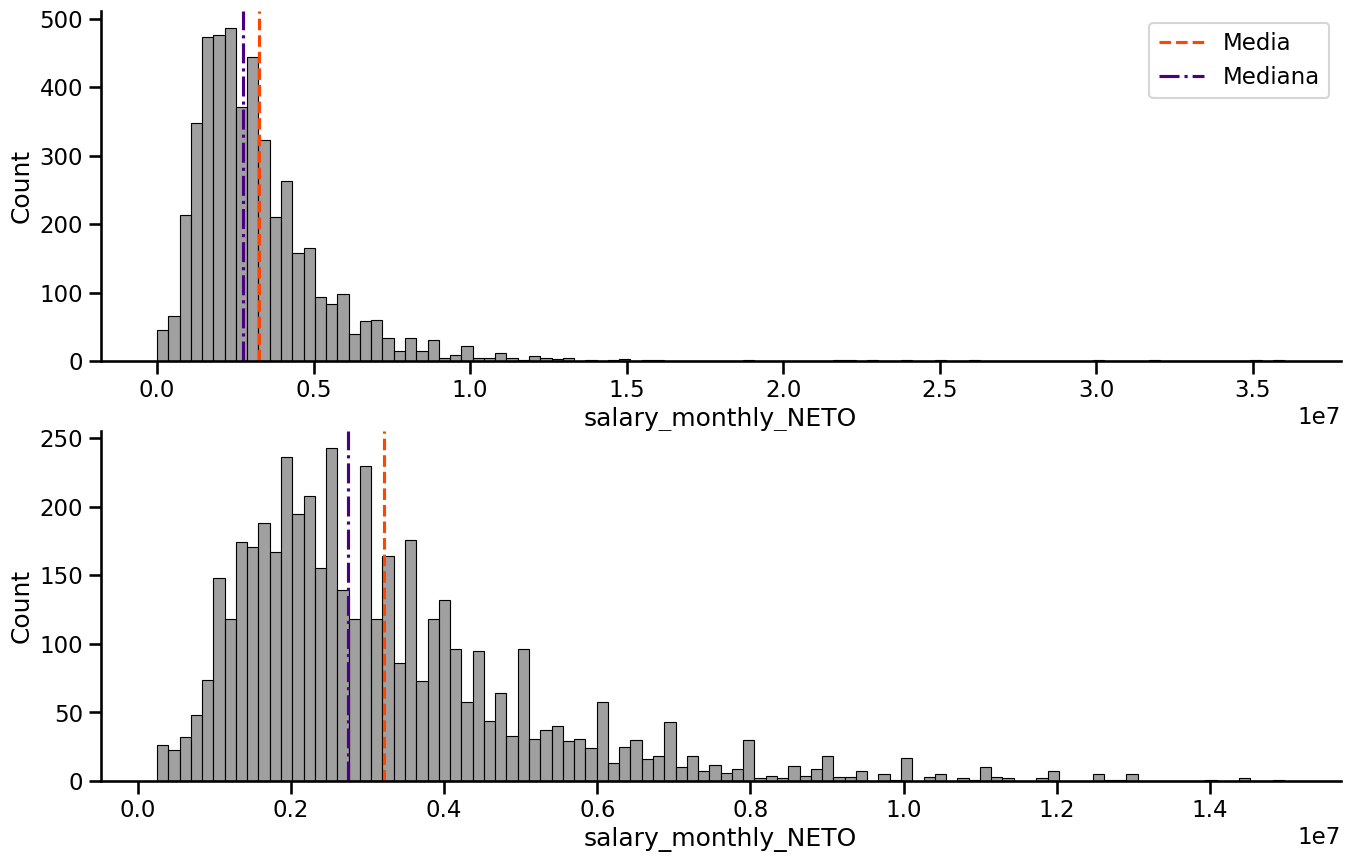

In [23]:
#Histograma que compara la distribución completa (quitando superiores a 50M)
# y la distribución filtrada de acuerdo a lower y upper, para comparar ambas
# distribuciones.

fig, axes = plt.subplots(nrows=2, figsize=(16, 10))

df_50m = df[df['salary_monthly_NETO'] < 50_000_000]
seaborn.histplot(df_50m['salary_monthly_NETO'], bins=100, ax=axes[0], color='gray')
axes[0].axvline(df_50m['salary_monthly_NETO'].mean(), color='orangered',
            linestyle='--', label='Media')
axes[0].axvline(df_50m['salary_monthly_NETO'].median(), color='indigo',
            linestyle='-.', label='Mediana')


seaborn.histplot(df_filtrado['salary_monthly_NETO'], bins=100, ax=axes[1], color='gray')
axes[1].axvline(df_filtrado['salary_monthly_NETO'].mean(), color='orangered',
            linestyle='--', label='Media')
axes[1].axvline(df_filtrado['salary_monthly_NETO'].median(), color='indigo',
            linestyle='-.', label='Mediana')

axes[0].legend()
seaborn.despine()

In [24]:
# Analizamos la frecuencia de las variables relacionadas

df_filtrado['work_dedication'].value_counts(dropna=False)
# Tiene sentido trabajar solo con FT

work_dedication
Full-Time    4474
Part-Time     196
Name: count, dtype: int64

In [25]:
df_filtrado['work_seniority'].value_counts(dropna=False)
# En este caso, es interesante analizar cada segmento de la muestra disponible

work_seniority
Senior         2717
Semi-Senior    1445
Junior          508
Name: count, dtype: int64

# Justificación

Los límites en torno al 1% (0,5% por lado) son justificables también por análisis visual (a partir de 15M la frecuencia es muy baja y pueden ser valores atípicos) y para el caso inferior, el 0.5% es similar al SMVM, que se ubica en torno a 300.000 mensuales y los programadores perciben salarios superiores, especialmente los Full-Time (los part-time son un grupo reducido, que además es heterogéneo internamente).
En el caso del "seniority", pueden analizarse las sub-poblaciones por separado. Estas variables no requieren eliminación de outliers o vacíos (en el análisis de frecuencias no se observan respuestas 'raras').

### ¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?
Como respuesta general, se pueden utilizar las estadísticas descriptivas de las variables, pero hacer foco en las medidas de asociación de las mismas: Coeficiente de correlación por ejemplo, o a través de herramientas visuales como ser el diagrama de dispersión (scatterplot) y analizar las densidades conjuntas. En las mismas se puede detectar si existe independencias de las variables y cómo se comportan las densidades condicionales.

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




### Respuesta
Las herramientas para detectar si existe algun tipo de relación o patrón entre variables es el diagrama de dispersión, junto con la distribución condicional de las variables que presenten patrones a partir de histogramas y boxplots (para variables categóricas por ejemplo).
Este análisis se puede complementar con el análisis del coeficiente de correlación para variables numericas (considerando que solo detecta relación lineal, y no estamos analizando causalidad).

###Selección de Variables:
*Numericas:*
- Salario Bruto: 'salary_monthly_BRUTO'
- Salario Neto: 'salary_monthly_NETO'
- Edad: 'profile_age'

*Categóricas*
- Seniority: 'work_seniority'
- Nivel de estudios:  'profile_studies_level'

Se revisaron las demás variables asociadas ('profile_studies_level_state','profile_career','profile_university') y podrían ser complementos interesantes: por ejemplo definir una nueva variable como el max nivel educativo finalizado, y crear categorías más generales: secundario o menos, universitario y terciario completo, posgrado completo.

Estas variables intuitivamente podrían estar estar relacionadas, y para poder graficar se trabaja de "a pares" de variables.

In [26]:
# Describe para las variables numericas
df[['salary_monthly_BRUTO','salary_monthly_NETO','profile_age']].describe()
# Para los salarios adoptaremos el limpiado de outliers conservando el 99% de la distribución, mientras que para edad
# se utilizará el criterio de "Edad laboral": mayores de 18 años, hasta 65 años (no distinguiremos entre hombres y mujeres)
# De esta manera, se eliminan valores como el max=999.

,salary_monthly_BRUTO,salary_monthly_NETO,profile_age
count,4.939000e+03,4.717000e+03,4939.000000
mean,3.876029e+06,3.599215e+06,37.505568
std,2.492699e+06,1.183755e+07,18.643457
min,2.000000e+05,1.600000e+00,16.000000
25%,2.166336e+06,1.850000e+06,30.000000
50%,3.268000e+06,2.750000e+06,36.000000
75%,4.944960e+06,4.000000e+06,43.000000
max,2.000000e+07,6.533882e+08,999.000000


In [27]:
df['profile_studies_level'].value_counts(dropna=False)
#Atención al nro de Nan: tmb puede deberse a la persistencia de la encuesta (hay muchas instancias de abandono)

profile_studies_level
NaN                         3178
Universitario               1175
Terciario                    272
Maestría                     108
Posgrado/Especialización     108
Secundario                    65
Doctorado                     27
Posdoctorado                   6
Name: count, dtype: int64

In [28]:
df['work_seniority'].value_counts(dropna=False)

work_seniority
Senior         2892
Semi-Senior    1514
Junior          533
Name: count, dtype: int64

In [29]:
# Vamos a definir el df filtrado
lower_bruto = df['salary_monthly_BRUTO'].quantile(0.005) # Los limites para el neto ya lo teniamos
upper_bruto = df['salary_monthly_BRUTO'].quantile(0.995)

df_filtered = df[
    (df['profile_age'].between(18, 65)) &
    (df['salary_monthly_NETO'].between(lower, upper)) &
    (df['salary_monthly_BRUTO'].between(lower_bruto, upper_bruto))
]
print(f"Filas originales:     {len(df)}")
print(f"Filas filtradas:      {len(df_filtered)}")
print(f"Rango edad:           18 — 65")
print(f"Rango salario neto:   {lower:.0f} — {upper:.0f}")
print(f"Rango salario bruto:  {lower_bruto:.0f} — {upper_bruto:.0f}")

Filas originales:     4939
Filas filtradas:      4626
Rango edad:           18 — 65
Rango salario neto:   250000 — 14983760
Rango salario bruto:  400000 — 15000000


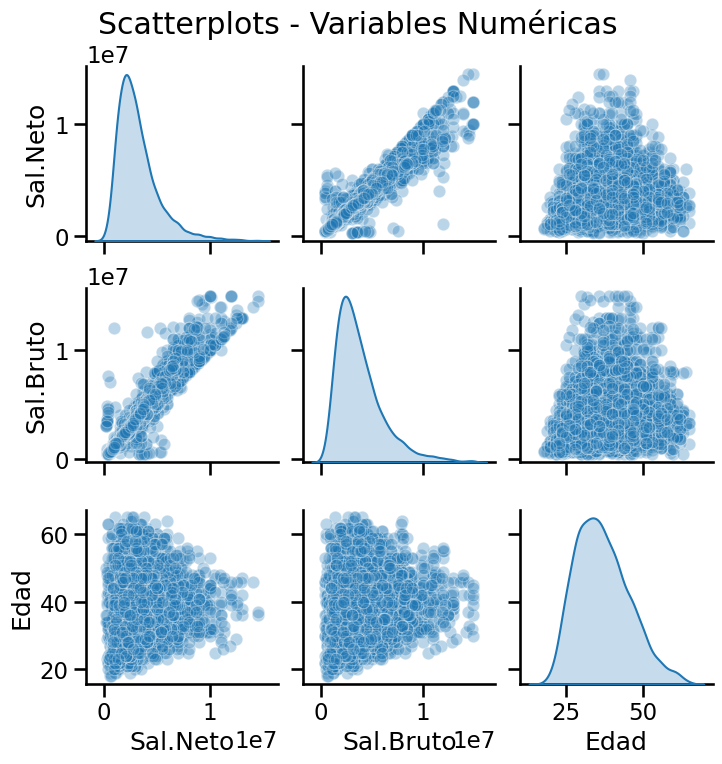

In [30]:
import seaborn as sns

num_cols = ['salary_monthly_NETO', 'salary_monthly_BRUTO', 'profile_age']

# Renombrar solo para el gráfico, sin modificar el df original
rename_dict = {
    'salary_monthly_NETO'  : 'Sal.Neto',
    'salary_monthly_BRUTO' : 'Sal.Bruto',
    'profile_age'          : 'Edad'
}

sns.pairplot(
    df_filtered[num_cols].rename(columns=rename_dict),
    diag_kind='kde', # muestra la densidad marginal en la diagonal
    plot_kws={'alpha': 0.3}
)
plt.suptitle('Scatterplots - Variables Numéricas', y=1.02)
plt.show()

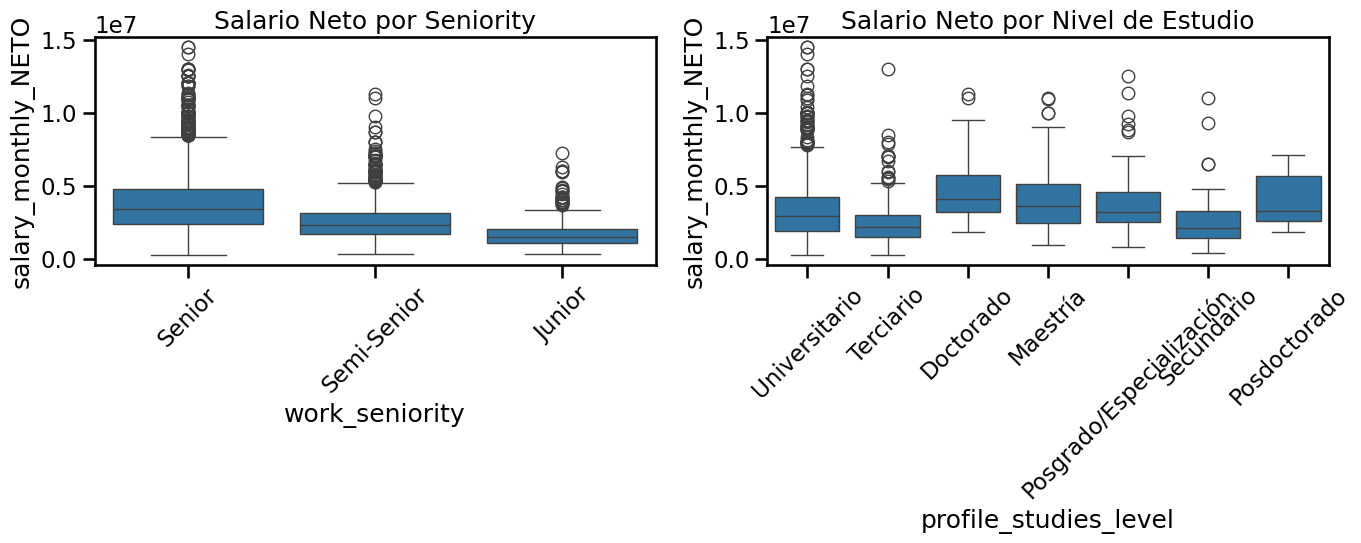

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Salario por seniority
sns.boxplot(data=df_filtered, x='work_seniority', y='salary_monthly_NETO', ax=axes[0])
axes[0].set_title('Salario Neto por Seniority')
axes[0].tick_params(axis='x', rotation=45)

# Salario por nivel de estudio
sns.boxplot(data=df_filtered, x='profile_studies_level', y='salary_monthly_NETO', ax=axes[1])
axes[1].set_title('Salario Neto por Nivel de Estudio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Complementamos grafico con estadísticas descriptivas (principalmente mediana y percentiles)
(df_filtered
.groupby('work_seniority')['salary_monthly_NETO']
.describe()
.sort_values('50%', ascending=False)
.apply(lambda col: col.map('{:.0f}'.format))
)

,count,mean,std,min,25%,50%,75%,max
work_seniority,,,,,,,,
Senior,2682,3842539,2119971,250000,2398278,3400000,4800000,14500000
Semi-Senior,1438,2561493,1306771,290000,1700000,2300000,3100000,11268613
Junior,506,1691749,926523,300000,1080000,1467500,2059185,7250000


In [33]:
# Ahora para el nivel de estudios
(df_filtered
 .groupby('profile_studies_level')['salary_monthly_NETO']
 .describe()
 .sort_values('50%', ascending=False)
 .apply(lambda col: col.map('{:.0f}'.format))
)

,count,mean,std,min,25%,50%,75%,max
profile_studies_level,,,,,,,,
Doctorado,26,4825339,2599423,1800000,3210145,4050000,5740000,11268613
Maestría,103,4139066,2221699,960153,2438590,3600000,5143730,11000000
Posdoctorado,6,4041000,2181438,1850000,2552000,3245000,5675000,7100000
Posgrado/Especialización,100,3828450,2185170,800000,2500000,3200000,4562500,12500000
Universitario,1117,3335966,2095046,250000,1900000,2944102,4200000,14500000
Terciario,256,2502538,1570109,260000,1500000,2135000,3000000,13000000
Secundario,62,2641296,1925459,400000,1402811,2084154,3230000,11000000


## Conclusiones
###Variables numericas

Entre salario bruto y neto se percibe una clara relación líneal y positiva, que se analizará en la siguiente sesión.
En cambio, para edad y salario (aplica a ambos) no se observa un patrón claro, más que una concentración de salarios superiores 10M en personas entre 25 y 50 años. Los salarios inferiores (hasta 500K) se distribuyen con cierta uniformidad a lo largo de las edades y a medida que se acercan al límite de 10M, comienzan a concentrarse más en torno al intervalo 25-50 años.

### Variables categóricas con Salario Neto

*Seniority*

En los box plots se observa que a medida que aumenta el seniority, los salarios medianos aumentan y se pueden extraer conclusiones como:
"El 25% de seniors que menos cobran presentan un techo salarial similar al 50% de semiseniors que menos cobran. Ocurre algo similar entre semi-seniors y juniors"
"El salario neto mediano de los seniors es superior al salario neto percibido por el 75% de los semi-seniors que menos cobran"

*Nivel Educativo*

Aclaración inicial: Exiten pocos casos para: Secundario(65), Doctorado(27) y Posdoctorado(6), por lo que serán excluidos del análisis. Se puede observar que a medida que crece el nivel educativo, los desarrolladores encuestados presentan un salario mediano mayor. Por ejemplo, el desarrollador mediano con nivel universitario encuestado cobra un salario neto similar al desarrollador con nivel terciario que ocupa el percentil 75. Lo mismo aplica para los desarrolladores con nivel posgrado o maestría respecto al terciario, pero no respecto al desarrollador con nivel universitario, lo que muestra que las diferencias entre categorías no son tan marcadas como para el seniority, y sería necesario complementar en análisis visual y descriptivo con otras medidas o test. Inlcuso a partir de este análisis inicial, se podrían juntar las categorías posgrado y maestría.

## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



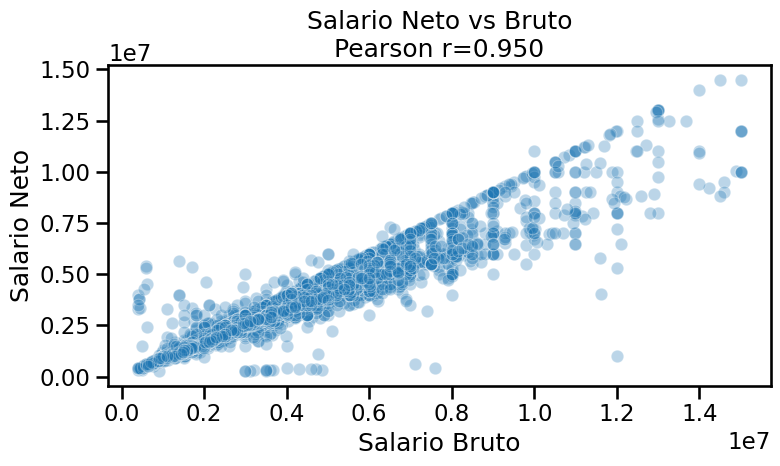

In [34]:
# Se utilizan los coeficientes de correlación lineal de Pearson
pearson_r = df_filtered['salary_monthly_NETO'].corr(df_filtered['salary_monthly_BRUTO'], method='pearson')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_filtered, x='salary_monthly_BRUTO', y='salary_monthly_NETO', alpha=0.3)
plt.title(f'Salario Neto vs Bruto\nPearson r={pearson_r:.3f}')
plt.xlabel('Salario Bruto')
plt.ylabel('Salario Neto')
plt.tight_layout()
plt.show()

# **Conclusiones**

A nivel gráfico (Scatterplot), y gracias al coeficiente de correlación lineal de Pearson se observa una fuerte correlación positiva, cercana a 1, por lo que se puede concluir que la relación lineal entre ambas variables es clara y no habría inconvenientes en descartar la variable de salario bruto para simplificar el DF, ya que "casi toda la información de la variable Salario Bruto está contenida en Salario Neto".

## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






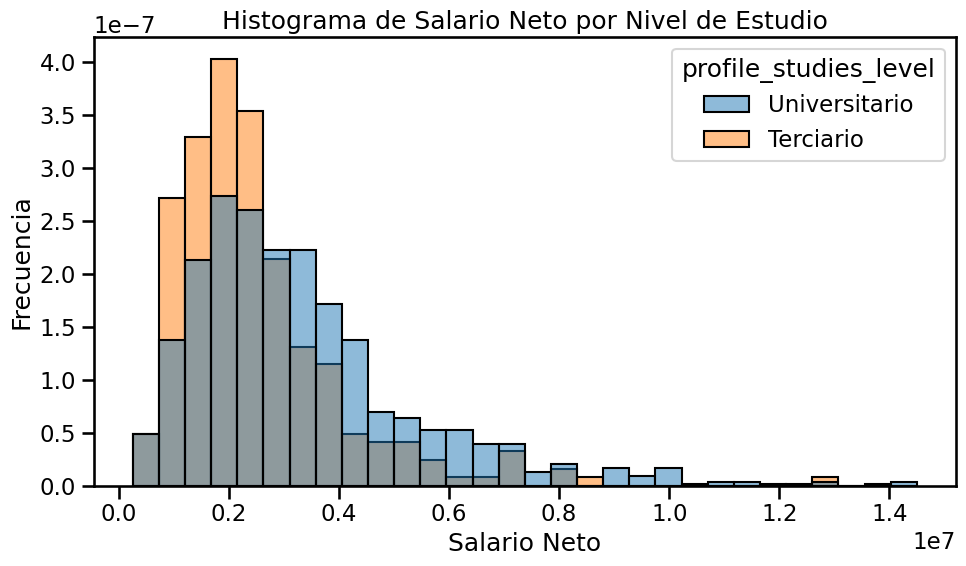

In [35]:
# Trabajamos con Universitario y terciario, las dos más frecuentes
estudios = ['Universitario', 'Terciario']

df_estudios = df_filtered[df_filtered['profile_studies_level'].isin(estudios)]
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_estudios,
    x='salary_monthly_NETO',
    hue='profile_studies_level',
    bins=30,
    alpha=0.5,
    common_norm=False,
    stat='density'  # sirve para normalizar para tamaños de poblaciones diferentes
)

plt.title('Histograma de Salario Neto por Nivel de Estudio')
plt.xlabel('Salario Neto')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

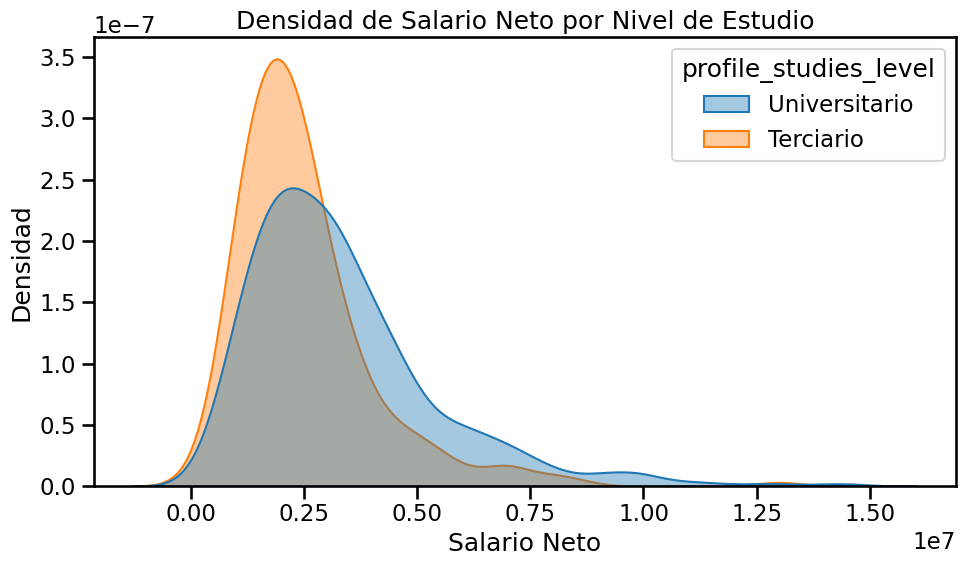

In [36]:
# Ahora con densidades
# Densidades superpuestas
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_estudios,
    x='salary_monthly_NETO',
    hue='profile_studies_level',
    fill=True,
    alpha=0.4,
    common_norm=False #Esto es para normalizar y poder superponerlas para tamaños diferentes.
)

plt.title('Densidad de Salario Neto por Nivel de Estudio')
plt.xlabel('Salario Neto')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

In [37]:
df_estudios.groupby('profile_studies_level')['salary_monthly_NETO'].describe().apply(lambda col: col.map('{:.0f}'.format))

,count,mean,std,min,25%,50%,75%,max
profile_studies_level,,,,,,,,
Terciario,256,2502538,1570109,260000,1500000,2135000,3000000,13000000
Universitario,1117,3335966,2095046,250000,1900000,2944102,4200000,14500000


In [38]:
# Agregamos asimetría y curtosis para validar lo que se observa en los gráficos
df_estudios.groupby('profile_studies_level')['salary_monthly_NETO'].agg(
    asimetria = lambda x: x.skew(),
    curtosis  = lambda x: x.kurt()
)

,asimetria,curtosis
profile_studies_level,,
Terciario,2.330061,9.147817
Universitario,1.640031,3.922558


# **Conclusiones:**
Los desarrolladores encuestados con nivel universitario presentan un mayor salario promedio que los que tienen nivel terciario. Sin embargo, como la distribuciones son asimétricas, no es una medida concluyente. Considerando además que existen diferencias en las medidas de asimetría y curtosis de las distribuciones condicionadas (asimetría más marcada en el caso de Terciario, que además presenta una distribución más concentrada en valores bajos y outliers de salarios elevados que hacen la cola de la distribución más pesada, es decir con mayor Curtosis -leptocúrtica), como así también en la mediana de los salarios netos, se puede concluir que ambas subpoblaciones no son independientes. Se debería complementar con un test de hipótesis para saber si las diferencias son significativas, pero las distribuciones empíricas no parecen ser independientes.

## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)


In [39]:
#Se utilizarán como variables numericas Salario Neto y Edad, y la variable
# categórica será género, acotado a las categorías más frecuentes. Las exploramos

df['profile_gender'].value_counts()

profile_gender
Hombre Cis           3861
Mujer Cis             983
Prefiero no decir      52
No binarie             22
Queer                  11
Trans                   8
Agénero                 1
Name: count, dtype: int64

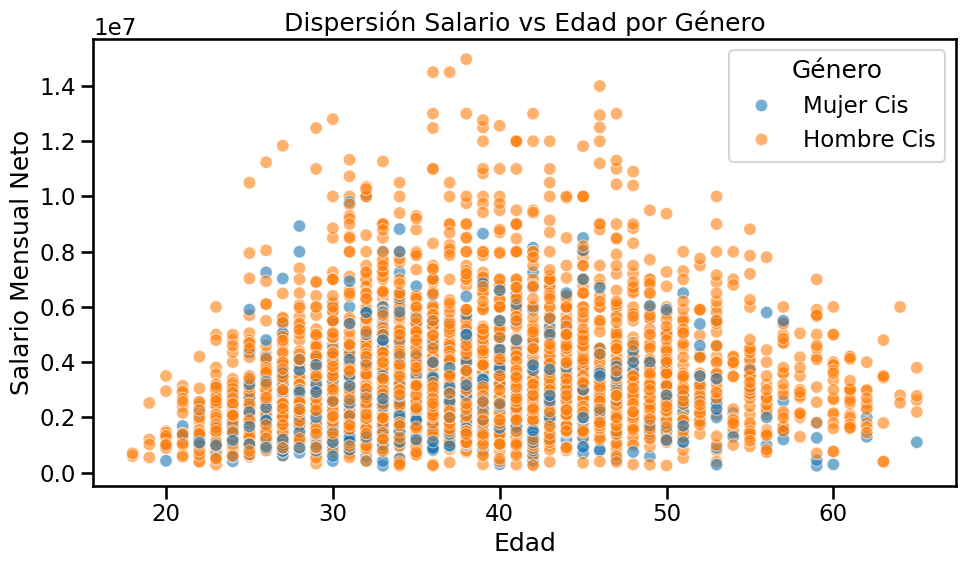

In [40]:
# Trabajamos con el df filtrado

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

df_filtered = df[
    (df['profile_age'].between(18, 65)) &
    (df['salary_monthly_NETO'].between(lower, upper)) &
    (df['profile_gender'].isin(['Hombre Cis', 'Mujer Cis']))
]

seaborn.scatterplot(
    data=df_filtered,
    x='profile_age',
    y='salary_monthly_NETO',
    hue='profile_gender',
    alpha=0.6,
    ax=axes
)
axes.set_title('Dispersión Salario vs Edad por Género')
axes.set_xlabel('Edad')
axes.set_ylabel('Salario Mensual Neto')
axes.legend(title='Género')

plt.tight_layout()
plt.show()

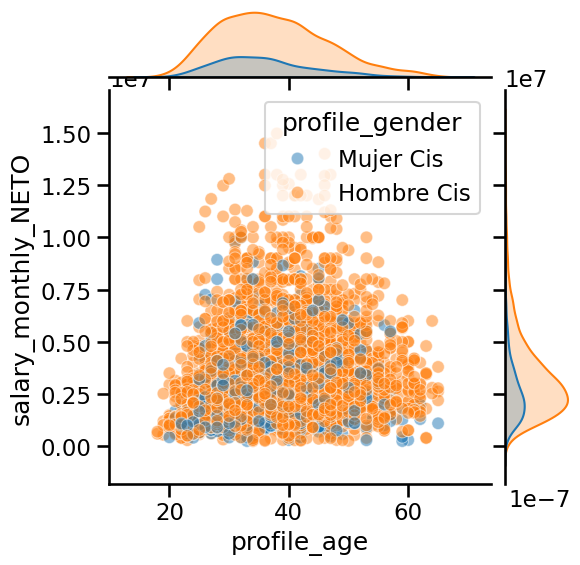

In [41]:
# Algunas recomendaciones de la IA para visualizar
# Joinplot para ver densidades marginales junto al scatterplot.

seaborn.jointplot(
    data=df_filtered,
    x='profile_age',
    y='salary_monthly_NETO',
    hue='profile_gender',
    alpha=0.5
)

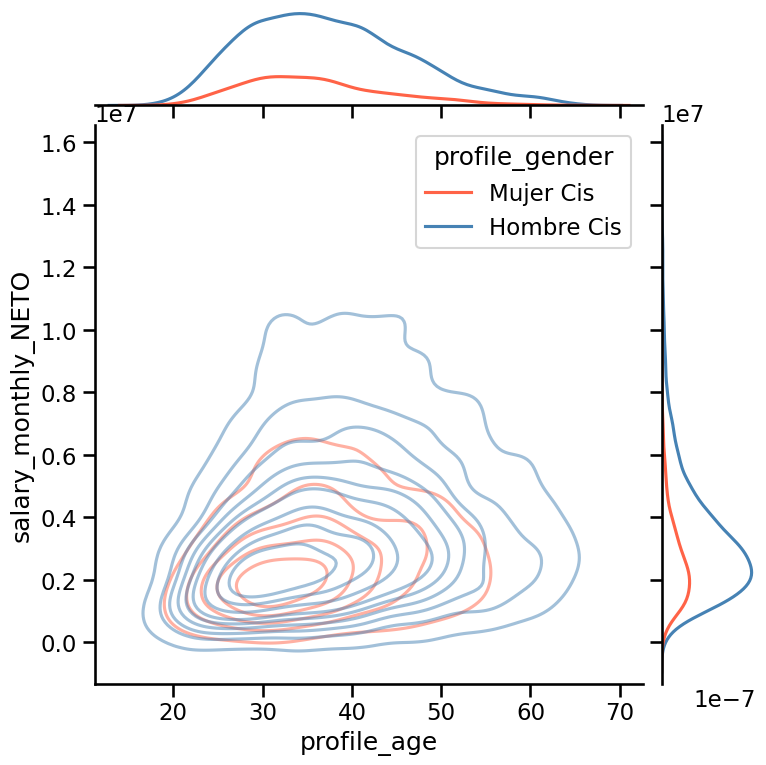

In [42]:
# Ahora con densidades en lugar de scatterplot
seaborn.jointplot(
    data=df_filtered,
    x='profile_age',
    y='salary_monthly_NETO',
    hue='profile_gender',
    kind='kde',
    palette={'Hombre Cis': 'steelblue', 'Mujer Cis': 'tomato'},
    alpha=0.5,
    height=8
)

#### Conclusiones

Los diferentes gráficos permiten analizar las distribuciones conjuntas de Salario Neto y Edad, condicionadas a valores de una variable categórica (hombres cis y mujeres cis, las categorías más frecuentes).

Ambos géneros tienen su concentración máxima alrededor de los 30-40 años y salarios de $2M-3M.
La distribución de Hombre Cis (azul) presenta mayor disperesión, con observaciones que se extienden hasta los 65 años y salarios cercanos a 10M (colas de la distribución).
La distribución de Mujer Cis (rojo) es más compacta y concentrada, con menor presencia en salarios altos y edades avanzadas. Esto podría sugerir que existe brecha salarial que se amplía con la edad.

Las distribuciones marginales condicionadas (en contraposición a la conjunta) permiten analizar cada distribución por separado también:

####Edad
Los Hombres Cis tienen una distribución más achatada y con cola más larga hacia la derecha (más representación en edades mayores)
Las Mujeres Cis tienen un pico más pronunciado y concentrado en edades jóvenes.

####Salario

Ambas distribuciones son asimétricas hacia la derecha (cola larga en salarios altos).
La distribución de Hombres Cis tiene una cola derecha más extendida, confirmando mayor presencia en salarios altos.
Las Mujeres Cis están más concentradas en el rango bajo-medio